Урок 36
Сулейменова Инкара

In [48]:
import torch #основная библиотека
import torch.nn as nn #модуль для работы с нейронными сетями
import torch.optim as optim #модель оптимизации 

import kagglehub 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from imblearn.over_sampling import SMOTE

In [2]:
path = kagglehub.dataset_download("kanchana1990/nasa-exoplanet-archive-intelligence")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Админ\.cache\kagglehub\datasets\kanchana1990\nasa-exoplanet-archive-intelligence\versions\1


In [5]:
nasa_df = pd.read_csv(f'{path}/nasa_exoplanet_intelligence.csv')
nasa_df

,planet_name,host_star,n_stars,n_planets,discovery_method,disc_year,disc_facility,orbital_period_days,planet_radius_earth,planet_mass_earth,...,ra,dec,controversial_flag,planet_type,habitable_zone_flag,multi_planet_system,is_recent_discovery,dist_category,star_type,orbital_period_cat
0,Kepler-1167 b,Kepler-1167,1,1,Transit,2016.0,Kepler,1.003934,1.710000,3.570000,...,298.302660,47.693965,0,Super-Earth,False,False,False,Far(500-2kpc),K-type,Short(1-10d)
1,Kepler-1740 b,Kepler-1740,1,1,Transit,2021.0,Kepler,8.172400,3.323214,11.000000,...,293.873663,38.922455,0,Mini-Neptune,False,False,True,Far(500-2kpc),G-type(Sun-like),Short(1-10d)
2,Kepler-1581 b,Kepler-1581,1,1,Transit,2016.0,Kepler,6.283855,0.800000,0.437000,...,287.371320,39.603623,0,Sub-Earth,False,False,False,Mid(100-500pc),F-type,Short(1-10d)
3,Kepler-644 b,Kepler-644,1,1,Transit,2016.0,Kepler,3.173917,3.150000,10.100000,...,295.475702,43.493112,0,Mini-Neptune,False,False,False,Far(500-2kpc),F-type,Short(1-10d)
4,Kepler-1752 b,Kepler-1752,1,1,Transit,2021.0,Kepler,56.358501,4.540605,18.700000,...,290.854140,51.222743,0,Neptune-like,False,False,True,Far(500-2kpc),G-type(Sun-like),Medium(10-100d)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6145,KMT-2024-BLG-1870L b,KMT-2024-BLG-1870L,1,1,Microlensing,2026.0,KMTNet,NaN,13.800000,336.898111,...,272.465333,-26.882889,0,Gas Giant,False,False,True,Distant(2k+pc),Unknown,Unknown
6146,TOI-2267 b,TOI-2267 A,2,3,Transit,2025.0,Transiting Exoplanet Survey Satellite (TESS),2.289090,1.000000,0.972000,...,65.061496,84.900824,0,Super-Earth,False,True,True,Nearby(<100pc),M-type(Red Dwarf),Short(1-10d)
6147,TOI-813 b,TOI-813,1,1,Transit,2020.0,Transiting Exoplanet Survey Satellite (TESS),83.891100,6.710000,36.400000,...,72.694010,-60.905461,0,Gas Giant,False,False,True,Mid(100-500pc),G-type(Sun-like),Medium(10-100d)
6148,LHS 1903 b,LHS 1903,1,4,Transit,2026.0,Transiting Exoplanet Survey Satellite (TESS),2.155510,1.382000,3.280000,...,107.865826,48.327933,0,Super-Earth,False,True,True,Nearby(<100pc),M-type(Red Dwarf),Short(1-10d)


In [6]:
nasa_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6150 entries, 0 to 6149
Data columns (total 31 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   planet_name           6150 non-null   str    
 1   host_star             6150 non-null   str    
 2   n_stars               6150 non-null   int64  
 3   n_planets             6150 non-null   int64  
 4   discovery_method      6150 non-null   str    
 5   disc_year             6149 non-null   float64
 6   disc_facility         6150 non-null   str    
 7   orbital_period_days   5816 non-null   float64
 8   planet_radius_earth   6100 non-null   float64
 9   planet_mass_earth     6119 non-null   float64
 10  equilibrium_temp_k    4587 non-null   float64
 11  orbital_eccentricity  5212 non-null   float64
 12  semi_major_axis_au    5834 non-null   float64
 13  star_temp_k           5860 non-null   float64
 14  star_radius_sun       5836 non-null   float64
 15  star_mass_sun         6142 non-n

In [7]:
pd.set_option('display.max_columns', None)
nasa_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6150 entries, 0 to 6149
Data columns (total 31 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   planet_name           6150 non-null   str    
 1   host_star             6150 non-null   str    
 2   n_stars               6150 non-null   int64  
 3   n_planets             6150 non-null   int64  
 4   discovery_method      6150 non-null   str    
 5   disc_year             6149 non-null   float64
 6   disc_facility         6150 non-null   str    
 7   orbital_period_days   5816 non-null   float64
 8   planet_radius_earth   6100 non-null   float64
 9   planet_mass_earth     6119 non-null   float64
 10  equilibrium_temp_k    4587 non-null   float64
 11  orbital_eccentricity  5212 non-null   float64
 12  semi_major_axis_au    5834 non-null   float64
 13  star_temp_k           5860 non-null   float64
 14  star_radius_sun       5836 non-null   float64
 15  star_mass_sun         6142 non-n

In [8]:
nasa_df['planet_type'].value_counts()

planet_type
Mini-Neptune     2148
Gas Giant        1734
Super-Earth      1185
Neptune-like      479
Super-Jupiter     324
Sub-Earth         230
Unknown            50
Name: count, dtype: int64

In [9]:
nasa_df.isnull().sum()

planet_name                0
host_star                  0
n_stars                    0
n_planets                  0
discovery_method           0
disc_year                  1
disc_facility              0
orbital_period_days      334
planet_radius_earth       50
planet_mass_earth         31
equilibrium_temp_k      1563
orbital_eccentricity     938
semi_major_axis_au       316
star_temp_k              290
star_radius_sun          314
star_mass_sun              8
star_age_gyr            1311
star_surface_gravity     318
star_metallicity         550
dist_from_earth_pc        27
star_vmag                295
ra                         0
dec                        0
controversial_flag         0
planet_type                0
habitable_zone_flag        0
multi_planet_system        0
is_recent_discovery        0
dist_category              0
star_type                  0
orbital_period_cat         0
dtype: int64

In [10]:
for col in nasa_df.columns:
   if nasa_df[col].dtypes in ['int64', 'float64']:
      nasa_df[col] = nasa_df[col].fillna(nasa_df[col].median())
   else:
      nasa_df[col] = nasa_df[col].fillna(nasa_df[col].mode()[0])

In [11]:
nasa_df.isnull().sum()

planet_name             0
host_star               0
n_stars                 0
n_planets               0
discovery_method        0
disc_year               0
disc_facility           0
orbital_period_days     0
planet_radius_earth     0
planet_mass_earth       0
equilibrium_temp_k      0
orbital_eccentricity    0
semi_major_axis_au      0
star_temp_k             0
star_radius_sun         0
star_mass_sun           0
star_age_gyr            0
star_surface_gravity    0
star_metallicity        0
dist_from_earth_pc      0
star_vmag               0
ra                      0
dec                     0
controversial_flag      0
planet_type             0
habitable_zone_flag     0
multi_planet_system     0
is_recent_discovery     0
dist_category           0
star_type               0
orbital_period_cat      0
dtype: int64

In [12]:
nasa_df.nunique()

planet_name             6150
host_star               4582
n_stars                    4
n_planets                  8
discovery_method          11
disc_year                 34
disc_facility             73
orbital_period_days     5803
planet_radius_earth     2136
planet_mass_earth       2817
equilibrium_temp_k      1876
orbital_eccentricity     611
semi_major_axis_au      3537
star_temp_k             2296
star_radius_sun         1809
star_mass_sun           1206
star_age_gyr             662
star_surface_gravity    1250
star_metallicity         618
dist_from_earth_pc      4469
star_vmag               3220
ra                      4579
dec                     4579
controversial_flag         2
planet_type                7
habitable_zone_flag        2
multi_planet_system        2
is_recent_discovery        2
dist_category              5
star_type                  8
orbital_period_cat         6
dtype: int64

In [13]:
nasa_df = nasa_df.drop(columns=['planet_name'])

In [14]:
nasa_df.duplicated().sum()

np.int64(0)

In [15]:
nasa_num_df = nasa_df.select_dtypes(include=['int64', 'float64'])

In [16]:
nasa_num_df.nunique()

n_stars                    4
n_planets                  8
disc_year                 34
orbital_period_days     5803
planet_radius_earth     2136
planet_mass_earth       2817
equilibrium_temp_k      1876
orbital_eccentricity     611
semi_major_axis_au      3537
star_temp_k             2296
star_radius_sun         1809
star_mass_sun           1206
star_age_gyr             662
star_surface_gravity    1250
star_metallicity         618
dist_from_earth_pc      4469
star_vmag               3220
ra                      4579
dec                     4579
controversial_flag         2
dtype: int64

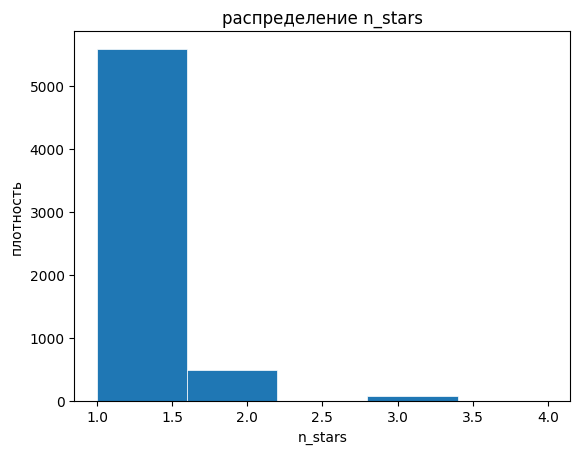

In [19]:
plt.hist(
   nasa_num_df['n_stars'],
   bins=5,
   edgecolor='white',
   linewidth=0.5
)
plt.title('распределение n_stars')
plt.xlabel('n_stars')
plt.ylabel('плотность')
plt.show()

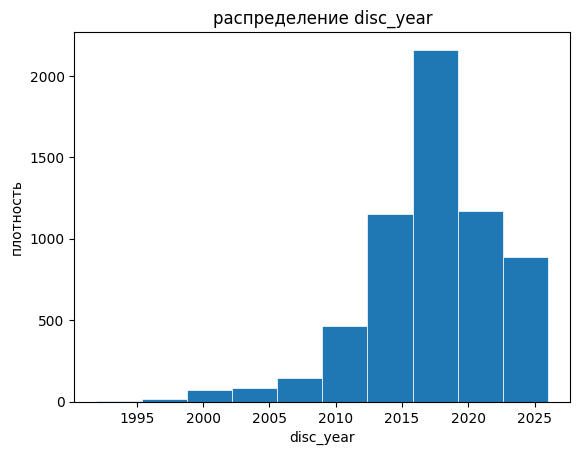

In [20]:
plt.hist(
   nasa_num_df['disc_year'],
   bins=10,
   edgecolor='white',
   linewidth=0.5)
plt.title('распределение disc_year')
plt.xlabel('disc_year')
plt.ylabel('плотность')
plt.show()

In [21]:
df_num = nasa_num_df.drop(columns=['n_stars', 'n_planets', 'controversial_flag', 'disc_year'])

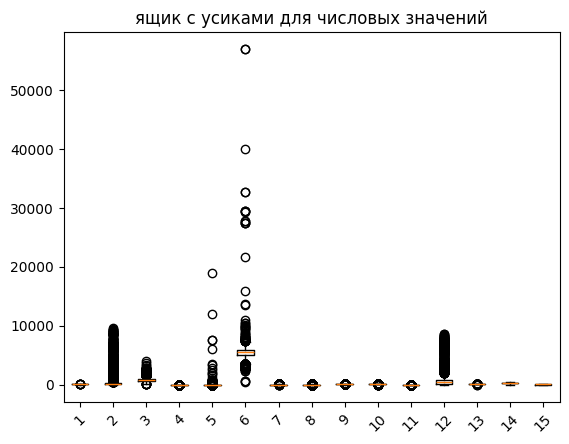

In [22]:
plt.boxplot(df_num[['planet_radius_earth', 'planet_mass_earth',
       'equilibrium_temp_k', 'orbital_eccentricity', 'semi_major_axis_au',
       'star_temp_k', 'star_radius_sun', 'star_mass_sun', 'star_age_gyr',
       'star_surface_gravity', 'star_metallicity', 'dist_from_earth_pc',
       'star_vmag', 'ra', 'dec']])
plt.title('ящик с усиками для числовых значений')
plt.xticks(rotation=45)
plt.show()

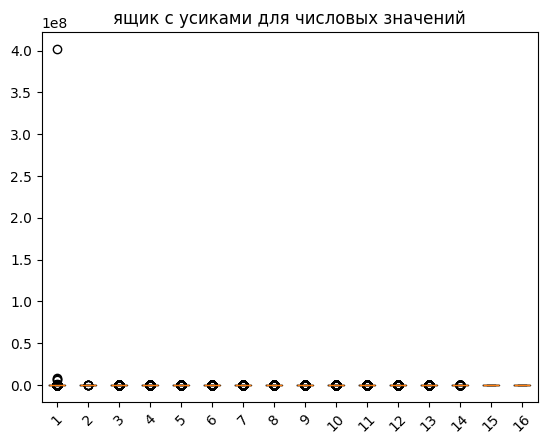

In [23]:
plt.boxplot(df_num)
plt.title('ящик с усиками для числовых значений')
plt.xticks(rotation=45)
plt.show()

In [24]:
q1 = df_num.quantile(0.25)
q3 = df_num.quantile(0.75)

iqr = q3 - q1

upper_b = q3 + 1.5 * iqr
lower_b = q1 - 1.5 * iqr

noise = (lower_b > df_num) | (upper_b < df_num)
noise_idx = df_num[noise.sum(axis=1) >= 2].index
noise_idx.shape

(1833,)

In [25]:
nasa_df.shape

(6150, 30)

In [26]:
nasa_df = nasa_df.drop(index=noise_idx)
nasa_df.shape

(4317, 30)

<Axes: >

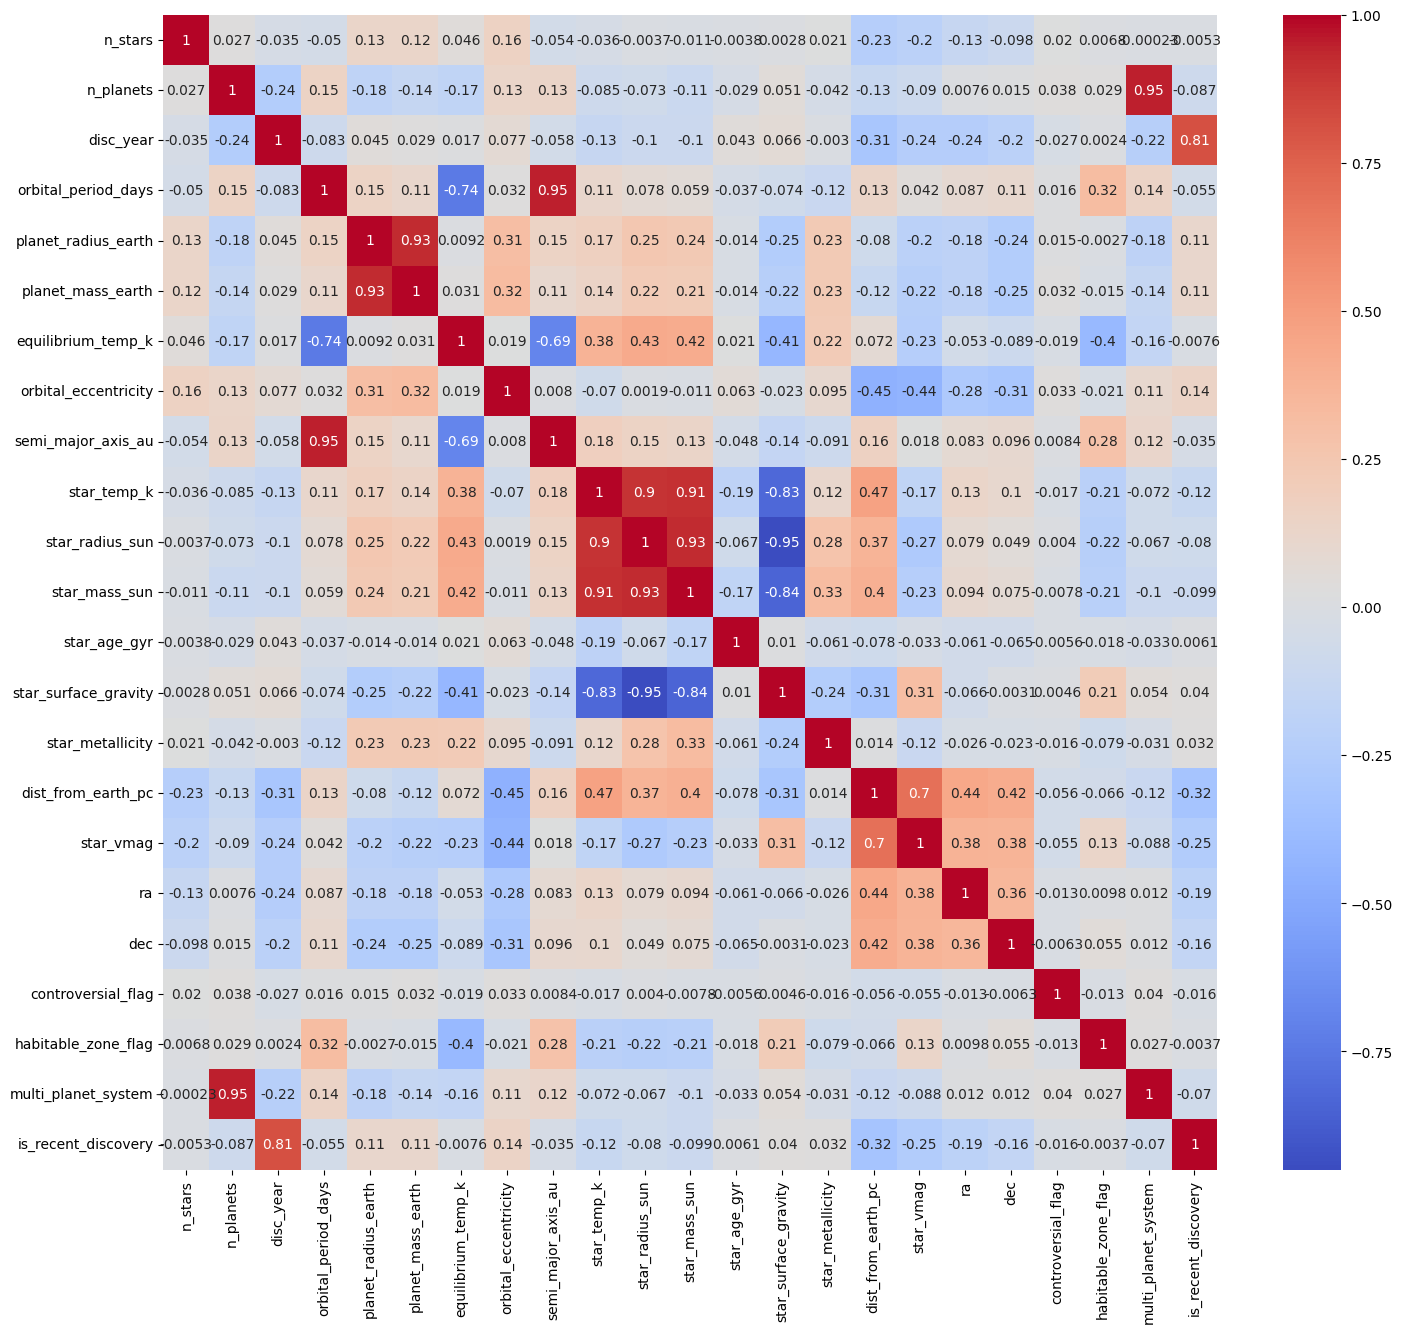

In [27]:
plt.figure(figsize=(17,15))
sns.heatmap(nasa_df.corr(method='spearman', numeric_only=True), cmap='coolwarm', annot=True)

In [28]:
nasa_df = nasa_df.drop(columns=['orbital_period_days', 'multi_planet_system', 'star_surface_gravity'])

In [29]:
nasa_df['planet_type'].value_counts()

planet_type
Mini-Neptune     1967
Super-Earth      1050
Gas Giant         558
Neptune-like      378
Sub-Earth         198
Super-Jupiter     147
Unknown            19
Name: count, dtype: int64

In [31]:
le = LabelEncoder()

for col in nasa_df.columns:
   if nasa_df[col].dtypes in ['str']: 
      nasa_df[col] = le.fit_transform(nasa_df[col])

nasa_df

,host_star,n_stars,n_planets,discovery_method,disc_year,disc_facility,planet_radius_earth,planet_mass_earth,equilibrium_temp_k,orbital_eccentricity,semi_major_axis_au,star_temp_k,star_radius_sun,star_mass_sun,star_age_gyr,star_metallicity,dist_from_earth_pc,star_vmag,ra,dec,controversial_flag,planet_type,habitable_zone_flag,is_recent_discovery,dist_category,star_type,orbital_period_cat
0,926,1,1,5,2016.0,22,1.710000,3.57000,1419.0,0.0000,0.01750,4971.00,0.75000,0.790,4.27,-0.05,820.9050,16.0470,298.302660,47.693965,0,4,False,False,1,2,2
1,1518,1,1,5,2021.0,22,3.323214,11.00000,858.0,0.0000,0.07790,5705.00,0.90500,0.943,3.98,-0.06,1061.7700,15.4540,293.873663,38.922455,0,1,False,True,1,1,2
2,1371,1,1,5,2016.0,22,0.800000,0.43700,1108.0,0.0000,0.06865,6022.00,1.23000,1.120,4.17,0.07,493.1750,12.4420,287.371320,39.603623,0,3,False,False,2,0,2
3,2226,1,1,5,2016.0,22,3.150000,10.10000,1655.0,0.0000,0.04641,6747.00,1.81000,1.490,1.62,0.08,1318.0500,14.0310,295.475702,43.493112,0,1,False,False,1,0,2
4,1529,1,1,5,2021.0,22,4.540605,18.70000,419.0,0.0000,0.26980,5446.00,0.82100,0.824,7.20,-0.20,962.8880,16.0249,290.854140,51.222743,0,2,False,True,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6136,3020,1,1,5,2026.0,45,3.710000,13.30000,872.0,0.0000,0.02870,4080.00,0.56400,0.583,3.98,-0.11,184.1200,14.1610,299.513133,55.651029,0,2,False,True,2,2,2
6139,568,3,2,5,2019.0,16,11.276254,246.00042,676.0,0.0000,0.30500,6302.00,1.51100,1.194,4.00,-0.06,272.9090,11.1140,234.857885,-20.198898,0,0,False,False,2,0,1
6141,33,1,1,4,2026.0,32,9.130000,61.39000,818.0,0.1000,0.05873,5996.82,1.53949,1.090,3.87,0.02,101.3860,8.7900,203.528465,0.498813,0,0,False,True,2,1,2
6144,3050,3,4,5,2019.0,16,6.530000,6.00000,831.0,0.0087,0.10810,4970.00,1.32000,1.100,0.02,0.10,108.1990,10.1150,61.331654,20.157032,0,0,False,False,2,2,1


In [32]:
bool_columns = nasa_df.select_dtypes(include='bool').columns

nasa_df[bool_columns] = nasa_df[bool_columns].astype(int)

In [33]:
X = nasa_df.drop(columns=['planet_type'])
y = nasa_df['planet_type']

In [34]:
nasa_df['planet_type'].value_counts()

planet_type
1    1967
4    1050
0     558
2     378
3     198
5     147
6      19
Name: count, dtype: int64

In [36]:
scaler = MinMaxScaler()
x_norm = scaler.fit_transform(X)

X = pd.DataFrame(x_norm, columns=X.columns)
X

,host_star,n_stars,n_planets,discovery_method,disc_year,disc_facility,planet_radius_earth,planet_mass_earth,equilibrium_temp_k,orbital_eccentricity,semi_major_axis_au,star_temp_k,star_radius_sun,star_mass_sun,star_age_gyr,star_metallicity,dist_from_earth_pc,star_vmag,ra,dec,controversial_flag,habitable_zone_flag,is_recent_discovery,dist_category,star_type,orbital_period_cat
0,0.290100,0.0,0.000000,0.833333,0.705882,0.448980,0.048249,0.000399,0.412762,0.000000,0.006106,0.481452,0.102041,0.417219,0.286577,0.596026,0.116193,0.769836,0.828588,0.776168,0.0,0.0,0.0,0.25,0.50,0.4
1,0.475564,0.0,0.000000,0.833333,0.852941,0.448980,0.103839,0.001234,0.226321,0.000000,0.034256,0.678763,0.133673,0.518543,0.267114,0.589404,0.150423,0.731638,0.816278,0.726040,0.0,0.0,1.0,0.25,0.25,0.4
2,0.429511,0.0,0.000000,0.833333,0.705882,0.448980,0.016892,0.000047,0.309405,0.000000,0.029945,0.763978,0.200000,0.635762,0.279866,0.675497,0.069619,0.537623,0.798205,0.729933,0.0,0.0,0.0,0.50,0.00,0.4
3,0.697368,0.0,0.000000,0.833333,0.705882,0.448980,0.097870,0.001133,0.491193,0.000000,0.019580,0.958871,0.318367,0.880795,0.108725,0.682119,0.186843,0.639977,0.820730,0.752161,0.0,0.0,0.0,0.25,0.00,0.4
4,0.479010,0.0,0.000000,0.833333,0.852941,0.448980,0.145788,0.002099,0.080425,0.000000,0.123695,0.609140,0.116531,0.439735,0.483221,0.496689,0.136371,0.768412,0.807885,0.796335,0.0,0.0,1.0,0.25,0.25,0.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4312,0.946115,0.0,0.000000,0.833333,1.000000,0.918367,0.117167,0.001492,0.230974,0.000000,0.011326,0.241935,0.064082,0.280132,0.267114,0.556291,0.025699,0.648351,0.831952,0.821642,0.0,0.0,1.0,0.50,0.50,0.4
4313,0.177945,1.0,0.142857,0.833333,0.794118,0.326531,0.377890,0.027641,0.165836,0.000000,0.140101,0.839247,0.257347,0.684768,0.268456,0.589404,0.038316,0.452081,0.652249,0.388168,0.0,0.0,0.0,0.50,0.00,0.2
4314,0.010338,0.0,0.000000,0.666667,1.000000,0.653061,0.303933,0.006896,0.213028,0.107643,0.025322,0.757210,0.263161,0.615894,0.259732,0.642384,0.013941,0.302382,0.565172,0.506453,0.0,0.0,1.0,0.50,0.25,0.4
4315,0.955514,1.0,0.428571,0.833333,0.794118,0.326531,0.214340,0.000672,0.217348,0.009365,0.048331,0.481183,0.218367,0.622517,0.001342,0.695364,0.014909,0.387731,0.169950,0.618798,0.0,0.0,0.0,0.50,0.50,0.2


In [38]:
smote = SMOTE()
X, y = smote.fit_resample(X, y)

In [39]:
Counter(y)

Counter({4: 1967, 1: 1967, 3: 1967, 2: 1967, 0: 1967, 5: 1967, 6: 1967})

In [41]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [43]:
#перевод данных с df в numpy, а потом с numpy в tensor
X_train = torch.tensor(X_train.to_numpy(), dtype=torch.float32)
y_train = torch.tensor(y_train.to_numpy(), dtype=torch.long) #long = int, Но с большим диапазоном
X_test = torch.tensor(X_test.to_numpy(), dtype=torch.float32)
y_test = torch.tensor(y_test.to_numpy(), dtype=torch.long)

In [44]:
X.shape

(13769, 26)

In [ ]:
#архитектура нейронных сетей
class NasaNet(nn.Module): #nn.Module 
   def __init__(self): #__init__  запускает, self определяет с чем работаем
      super(NasaNet, self).__init__() #super используется при наследование, вызывает __init__ родительского класса nn.Module
      self.fc1 = nn.Linear(26, 100) #сюда пишем количество признаков вход -> скрытый
      self.fc2 = nn.Linear(100, 100) #скрытй -> скрытый
      self.fc3 = nn.Linear(100, 7) #количество классов целевой переменной скрытый -> выходной
   #все нейроны связаны, fc fully connected
   #Linear линейная комбинация
   def forward(self, x): #прямое прохождение данных через модель
      x = torch.relu(self.fc1(x)) #линейной слой закидываем в функцию активации
      x = torch.tanh(self.fc2(x))
      x = self.fc3(x)
      return x
   
model = NasaNet()#создаем объект модели, чтобы потом обучать ее и делать предсказания

In [ ]:
criterion = nn.CrossEntropyLoss() #ошибка, loss function, crossentropy для классификации mse для регрессии
optimizer = optim.Adam(model.parameters(), lr=0.01) #оптимизатор, можно подбирать параметры, lr learning rate

num_epochs = 100 #количество эпох, сколько будет прямых и обратных прохождений
losses = [] 
accuracies = []

for epoch in range(num_epochs): #проходим по эпохам в цикле

   output = model(X_train) #прямое прохождение, обучение
   loss = criterion(output, y_train) #считает loss функцию
   #для обратное прохождение
   optimizer.zero_grad() #обнуляем градиент чтобы не результаты не суммировались
   loss.backward() # обратное распределение ошибки, считает градиенты, производные
   optimizer.step() #обновляем весовые коэффициенты
 
   losses.append(loss.item()) #ошибки добавляем в список losses

   with torch.no_grad(): 

      outputs = model(X_test) #прогноз
      _, predicted = torch.max(outputs, 1) #максимальную вероятность среди других классов.
      acc = accuracy_score(y_test, predicted)
      accuracies.append(acc)

   if (epoch + 1) % 10 == 0:
      print(f'Epoch [{epoch + 1}/{num_epochs}], Loss: {loss.item():.4f}, Accuracy: {accuracies[-1]:.4f}')
      #Формат :.4f в Python используется для форматирования чисел с плавающей запятой (float), фиксируя отображение ровно 4 знаков после запятой
      

Epoch [10/100], Loss: 1.1901, Accuracy: 0.5211
Epoch [20/100], Loss: 0.8680, Accuracy: 0.6383
Epoch [30/100], Loss: 0.7283, Accuracy: 0.7400
Epoch [40/100], Loss: 0.5735, Accuracy: 0.7633
Epoch [50/100], Loss: 0.4844, Accuracy: 0.7992
Epoch [60/100], Loss: 0.3976, Accuracy: 0.8479
Epoch [70/100], Loss: 0.3428, Accuracy: 0.8780
Epoch [80/100], Loss: 0.3069, Accuracy: 0.8649
Epoch [90/100], Loss: 0.2970, Accuracy: 0.9147
Epoch [100/100], Loss: 0.2301, Accuracy: 0.9187


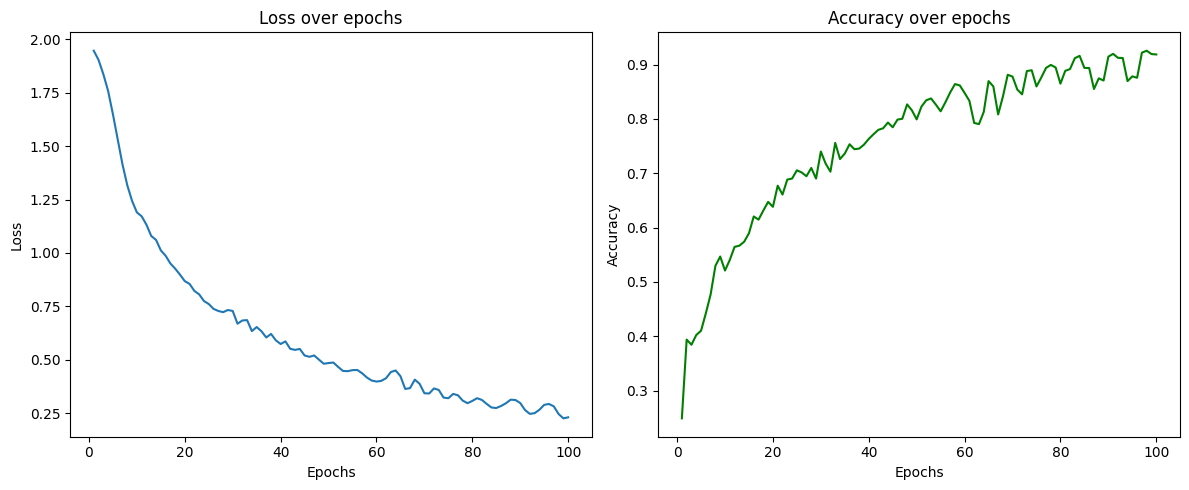

Final accuracy on test set: 0.9187


In [53]:
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs + 1), losses, label = 'Loss')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs + 1), accuracies, label='Accuracy', color='green')
plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.tight_layout()
plt.show()

with torch.no_grad():
   outputs = model(X_test)
   _, predicted = torch.max(outputs, 1)
   acc = accuracy_score(y_test, predicted)
   print(f'Final accuracy on test set: {acc:.4f}')